In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Goal 1: Nyquist Sampling

### Section 5.3.1

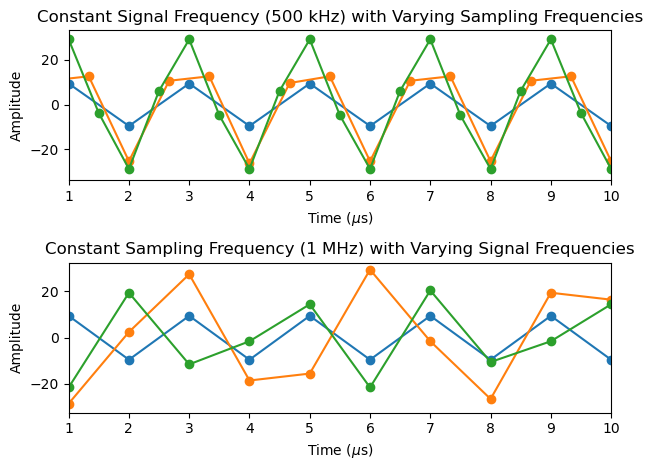

In [4]:
#data for signal frequency of 500 kHz, sampling frequency of 1MHz (Nyquist Limit)
data1 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_500kHz.npz")

#data for singal frequency 500kHz, sampling frequncy of 1MHz, 1.5MHz, and 2MHz
data2 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1.5MHz_500kHz.npz")
data3 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_2MHz_500kHz.npz")

#data for sampling frequency of 1.5MHz, signal frequency of 
data4 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
data5 = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_400kHz.npz")

D = 2 #what sample set (1, 2, 3, 4, or 5)

signal1 = data1["arr_0"][D]
signal2 = data2["arr_0"][D]
signal3 = data3["arr_0"][D]
signal4 = data4["arr_0"][D]
signal5 = data5["arr_0"][D]

signal1 = signal1 - np.mean(signal1)
signal2 = signal2 - np.mean(signal2)
signal3 = signal3 - np.mean(signal3)
signal4 = signal4 - np.mean(signal4)
signal5 = signal5 - np.mean(signal5)

time1 = np.arange(len(signal1)) / 1e6
time2 = np.arange(len(signal2)) / 1.5e6
time3 = np.arange(len(signal3)) / 2e6
time4 = np.arange(len(signal4)) / 1e6
time5 = np.arange(len(signal5)) / 1e6

plt.subplot(2,1,1)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time2 * 1e6, signal2, marker="o")
plt.plot(time3 * 1e6, signal3, marker="o")
plt.xlim(1, 10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Signal Frequency (500 kHz) with Varying Sampling Frequencies")

plt.subplot(2,1,2)
plt.plot(time1 * 1e6, signal1, marker="o")
plt.plot(time4 * 1e6, signal4, marker="o")
plt.plot(time5 * 1e6, signal5, marker="o")
plt.xlim(1,10)
plt.xlabel(r"Time ($\mu$s)")
plt.ylabel("Amplitude")
plt.title("Constant Sampling Frequency (1 MHz) with Varying Signal Frequencies")
plt.tight_layout()
plt.show()

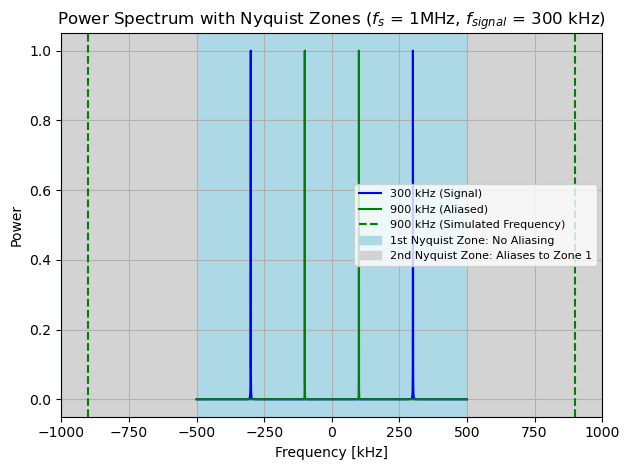

In [70]:
#Attempt to show first Nyquist Zone for signal 1, using 1MHz, 300kHz data (data4)
fs = 1e6 #Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 #Signal frequency (Hz)

#Variables for simulated signal
N = len(signal4)
time = np.arange(N) / fs
freq_sim1 = 900e3 #Simulated signal frequency (Hz)
signal_sim1 = np.cos(2*np.pi * freq_sim1 * time)

#Fourier Transform and Power Spectrum of Signal Data
spectrum = np.fft.fft(signal4)
freq = np.fft.fftfreq(len(signal4), d=1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

#Fourier Transform and Power Spectrum of Simulated 900 kHz Signal
spectrum_sim1 = np.fft.fft(signal_sim1)
power_sim1 = np.abs(np.fft.fftshift(spectrum_sim1))**2

#Labeling Nyquist Zones and Plotting Power Spectrum of 300 kHz signal and simulated 900 kHz signal
plt.plot(freqs_shift/1e3, power / np.max(power), color="blue", label="300 kHz (Signal)")
plt.plot(freqs_shift/1e3, power_sim1 / np.max(power_sim1), color="green", label="900 kHz (Aliased)")

#Labeling true frequency, simulated frequency, and aliased frequency

plt.axvline(freq_sim1/1e3, color="green", linestyle="--", label="900 kHz (Simulated Frequency)")
plt.axvline(-freq_sim1/1e3, color="green", linestyle="--")

#Showing Nyquist Zones
for zone in range(1, 4):
    boundaries = zone * nyquist_freq
    color = "lightblue" if zone % 2 == 1 else "lightgray"
    if zone == 1:
        label_pos = "1st Nyquist Zone: No Aliasing"
        label_neg = "_nolegend_"
    elif zone == 2:
        label_pos = "2nd Nyquist Zone: Aliases to Zone 1"
        label_neg = "_nolegend_"
    else:
        label_pos = "_nolegend_"
        label_neg = "_nolegend_"

    plt.axvspan((zone - 1) * nyquist_freq/1e3, zone * nyquist_freq/1e3, color=color, label=label_pos)
    plt.axvspan(-zone * nyquist_freq/1e3, -(zone - 1) * nyquist_freq/1e3, color=color, label=label_neg)


plt.xlabel("Frequency [kHz]")
plt.ylabel("Power")
plt.title("Power Spectrum with Nyquist Zones ($f_s$ = 1MHz, $f_{signal}$ = 300 kHz)")
plt.legend(fontsize = 8)
plt.xlim(-1000, 1000)
plt.grid()
plt.tight_layout()
plt.show()

## Goal 3: Bandpass Filter of SDR

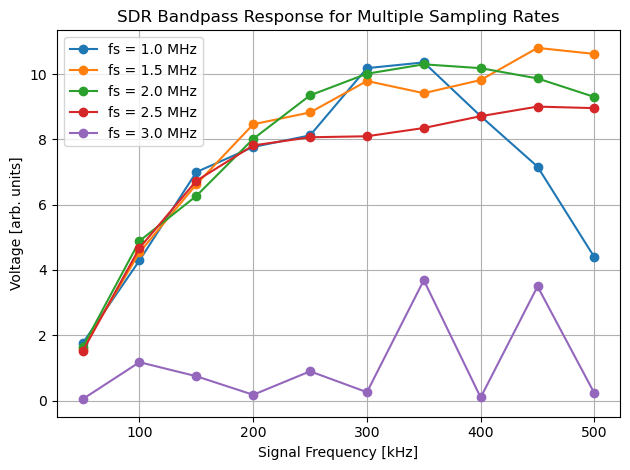

In [122]:
sampling_rates = [1e6, 1.5e6, 2e6, 2.5e6, 3e6] #Hz

files_by_fs = {
    1e6: ["C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_50kHz.npz", 
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_100kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_150kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_200kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_250kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_300kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_350kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_400kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_450kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1MHz_Sampling/test_1MHz_500kHz.npz"],

    1.5e6: ["C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_50kHz.npz", 
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_100kHz.npz", 
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_150kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_200kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_250kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_300kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_350kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_400kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_450kHz.npz",
           "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/1.5MHz_Sampling/test_1.5MHz_500kHz.npz"],
        
    2e6: ["C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_50kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_100kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_150kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_200kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_250kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_300kHz.npz", 
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_350kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_400kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_450kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2MHz_Sampling/test_2MHz_500kHz.npz"],

    2.5e6: ["C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_50kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_100kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_150kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_200kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_250kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_300kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_350kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_400kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_450kHz.npz",
            "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/2.5MHz_Sampling/test_2.5MHz_500kHz.npz"],

    3e6: ["C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_50kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_100kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_150kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_200kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_250kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_300kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_350kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_400kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_450kHz.npz",
          "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter/3MHz_Sampling/test_3MHz_500kHz.npz"] 
}

signal_freqs = np.array([50e3, 100e3, 150e3, 200e3, 250e3,
                         300e3, 350e3, 400e3, 450e3, 500e3])
N = 2046  # samples per block

import numpy as np

def extract_peak_magnitude(filename, fs, f_sig, N):
    """
    Extract the average FFT peak magnitude at f_sig from an SDR data file
    that may contain multiple blocks.
    
    Parameters:
        filename : str
            Path to .npz file (expects data in 'arr_0')
        fs : float
            Sampling frequency (Hz)
        f_sig : float
            Signal frequency (Hz)
        N : int
            Number of samples to use per block
    
    Returns:
        peak_mag : float
            Average FFT magnitude at the signal frequency across all blocks
    """
    # Load the data
    data = np.load(filename)['arr_0']  # shape: (num_blocks, samples_per_block)

    # Trim each block to N samples (along last axis)
    signal = data[:, :N]  # shape: (num_blocks, N)

    # Create Hann window
    window = np.hanning(N)

    # Apply window to each block (broadcasts correctly)
    signal_win = signal * window

    # FFT along samples axis
    spectrum_mag = np.abs(np.fft.fft(signal_win, axis=1))

    # Frequency array
    freqs = np.fft.fftfreq(N, d=1/fs)

    # Index of closest bin to f_sig
    idx = np.argmin(np.abs(freqs - f_sig))

    # Take the average magnitude across blocks
    peak_mag = np.mean(spectrum_mag[:, idx])

    return peak_mag


import matplotlib.pyplot as plt

plt.figure()

for fs in sampling_rates:
    magnitudes = []
    files = files_by_fs[fs]
    
    for f_sig, fname in zip(signal_freqs, files):
        peak_mag = extract_peak_magnitude(fname, fs, f_sig, N)
        magnitudes.append(peak_mag)
    
    # Convert to linear voltage
    fft_mag_volts = (np.array(magnitudes) / N) * 2
    
    # Plot
    plt.plot(signal_freqs / 1e3, fft_mag_volts, 'o-', label=f'fs = {fs/1e6} MHz')

plt.xlabel("Signal Frequency [kHz]")
plt.ylabel("Voltage [arb. units]")
plt.title("SDR Bandpass Response for Multiple Sampling Rates")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Goal 4: Spectral Leakage and Frequency Resolution

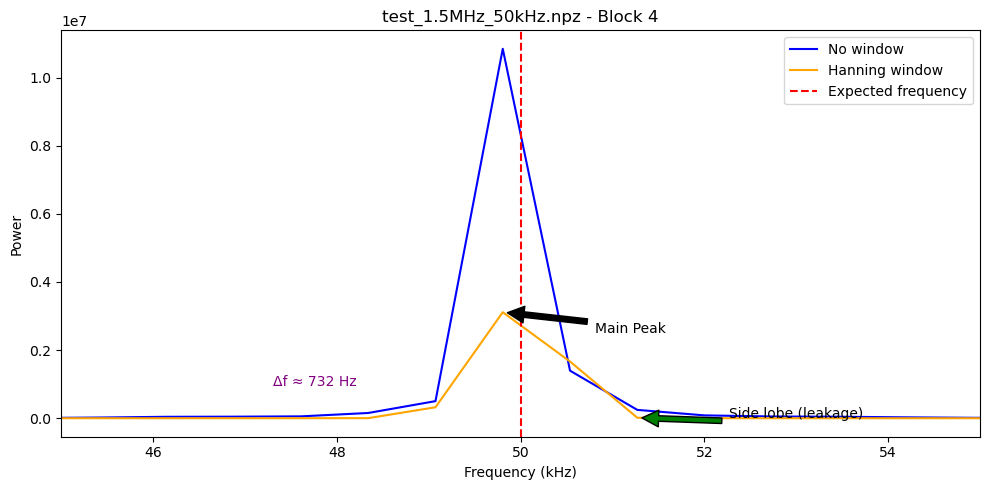

test_1.5MHz_50kHz.npz - Block 4: Frequency resolution Δf = 732.42 Hz


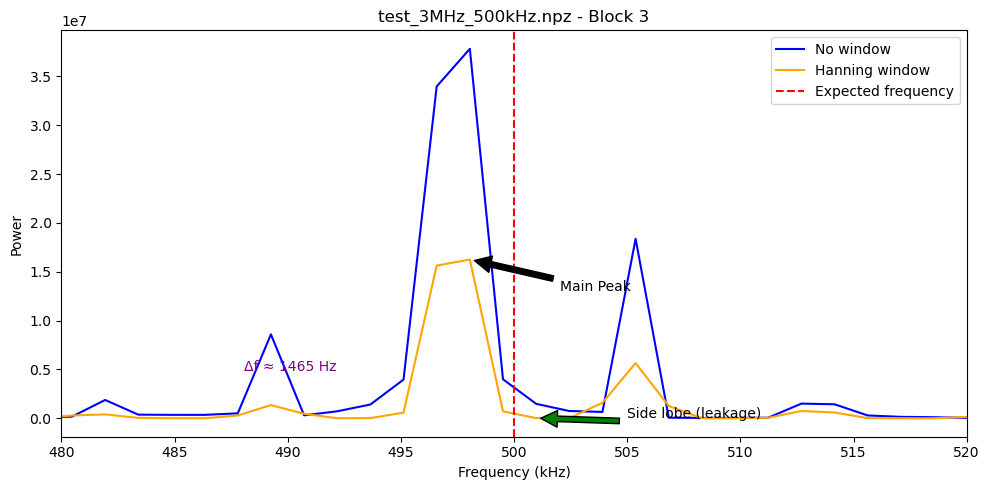

test_3MHz_500kHz.npz - Block 3: Frequency resolution Δf = 1464.84 Hz


In [155]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Dataset parameters
# -----------------------------
datasets = [
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\1.5MHz_Sampling\test_1.5MHz_50kHz.npz",
        "fs": 1.5e6,
        "f_signal": 50e3,
        "zoom_range_khz": 5,
        "block_idx": 3  # chosen representative block
    },
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz",
        "fs": 3e6,
        "f_signal": 500e3,
        "zoom_range_khz": 20,
        "block_idx": 2  # chosen representative block
    }
]

# -----------------------------
# Function to plot annotated spectrum
# -----------------------------
def plot_annotated_spectrum(x_block, fs, f_signal, zoom_range_khz, title):
    N = len(x_block)
    delta_f = fs / N
    
    # FFTs
    freqs = np.fft.fftfreq(N, 1/fs)
    window = np.hanning(N)
    
    X = np.fft.fft(x_block)
    Xw = np.fft.fft(x_block * window)
    
    power = np.abs(X)**2
    power_windowed = np.abs(Xw)**2
    
    # Zoom range
    zoom_min = f_signal - zoom_range_khz*1e3
    zoom_max = f_signal + zoom_range_khz*1e3
    
    plt.figure(figsize=(10,5))
    
    # Plot spectra
    plt.plot(freqs[:N//2]/1e3, power[:N//2], label='No window', color='blue')
    plt.plot(freqs[:N//2]/1e3, power_windowed[:N//2], label='Hanning window', color='orange')
    
    # Expected frequency line
    plt.axvline(f_signal/1e3, color='red', linestyle='--', label='Expected frequency')
    
    # Main peak annotation
    main_peak_idx = np.argmax(power_windowed)
    plt.annotate('Main Peak',
                 xy=(freqs[main_peak_idx]/1e3, power_windowed[main_peak_idx]),
                 xytext=(freqs[main_peak_idx]/1e3 + zoom_range_khz*0.2, power_windowed[main_peak_idx]*0.8),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    # Side lobe annotation (pick a nearby bin)
    if main_peak_idx + 2 < len(power_windowed):
        side_lobe_idx = main_peak_idx + 2
        plt.annotate('Side lobe (leakage)',
                     xy=(freqs[side_lobe_idx]/1e3, power_windowed[side_lobe_idx]),
                     xytext=(freqs[side_lobe_idx]/1e3 + zoom_range_khz*0.2, power_windowed[side_lobe_idx]*0.5),
                     arrowprops=dict(facecolor='green', shrink=0.05))
    
    # Δf marker annotation
    plt.annotate(f'Δf ≈ {delta_f:.0f} Hz',
                 xy=(freqs[main_peak_idx]/1e3 - zoom_range_khz*0.5, power_windowed[main_peak_idx]*0.3),
                 xytext=(freqs[main_peak_idx]/1e3 - zoom_range_khz*0.5, power_windowed[main_peak_idx]*0.3),
                 fontsize=10, color='purple')
    
    plt.xlim(zoom_min/1e3, zoom_max/1e3)
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"{title}: Frequency resolution Δf = {delta_f:.2f} Hz")

# -----------------------------
# Process both datasets
# -----------------------------
for ds in datasets:
    data = np.load(ds["file"])
    x = data[data.files[0]]
    
    # Ensure 2D: blocks × samples
    if x.ndim == 1:
        x = x[np.newaxis, :]
    
    block = x[ds["block_idx"]]
    title = f"{os.path.basename(ds['file'])} - Block {ds['block_idx'] + 1}"
    
    plot_annotated_spectrum(block, ds["fs"], ds["f_signal"], ds["zoom_range_khz"], title)


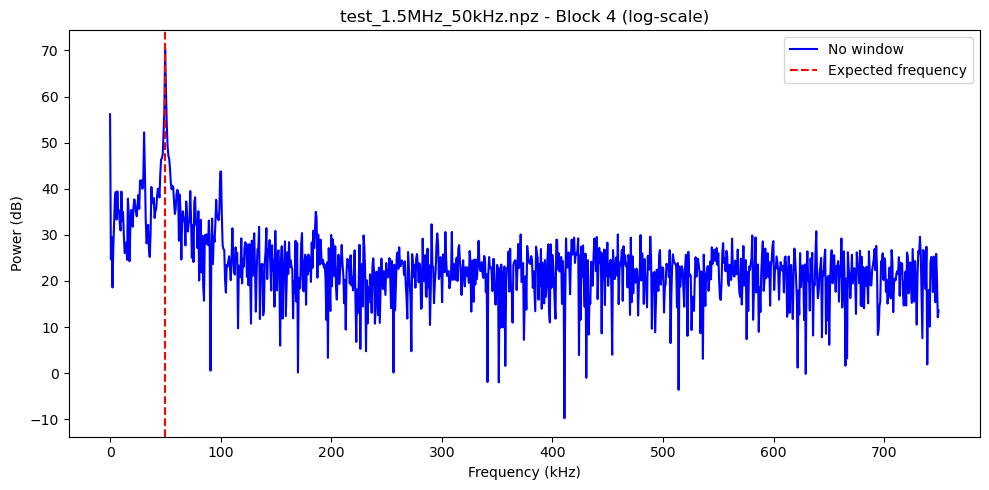

test_1.5MHz_50kHz.npz - Block 4: Frequency resolution Δf = 732.42 Hz


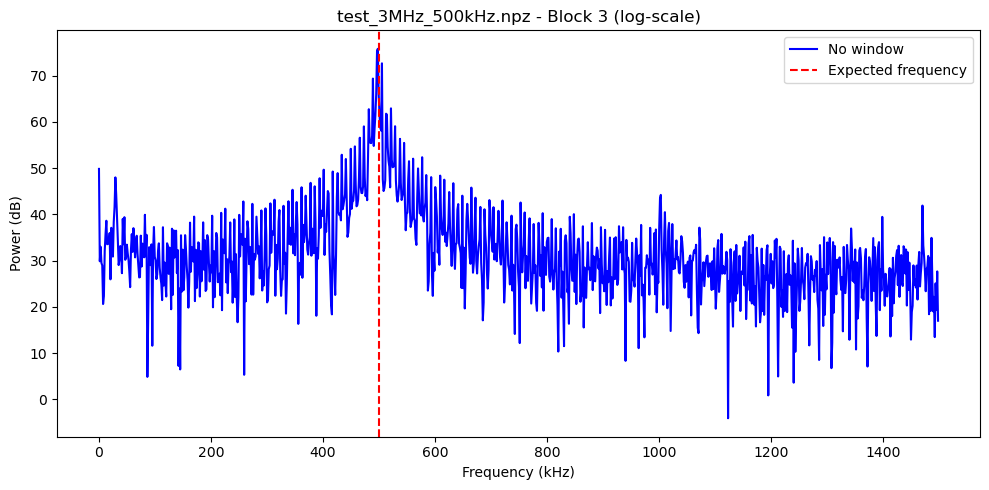

test_3MHz_500kHz.npz - Block 3: Frequency resolution Δf = 1464.84 Hz


In [160]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Dataset parameters
# -----------------------------
datasets = [
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\1.5MHz_Sampling\test_1.5MHz_50kHz.npz",
        "fs": 1.5e6,
        "f_signal": 50e3,
        "zoom_range_khz": 5,
        "block_idx": 3
    },
    {
        "file": r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz",
        "fs": 3e6,
        "f_signal": 500e3,
        "zoom_range_khz": 20,
        "block_idx": 2
    }
]

# -----------------------------
# Function to plot log-scale annotated spectrum
# -----------------------------
def plot_annotated_spectrum_log(x_block, fs, f_signal, zoom_range_khz, title):
    N = len(x_block)
    delta_f = fs / N
    
    freqs = np.fft.fftfreq(N, 1/fs)
    window = np.hanning(N)
    
    X = np.fft.fft(x_block)
    Xw = np.fft.fft(x_block * window)
    
    # Convert to dB (power)
    epsilon = 1e-12  # avoid log(0)
    power_dB = 10 * np.log10(np.abs(X)**2 + epsilon)
    power_windowed_dB = 10 * np.log10(np.abs(Xw)**2 + epsilon)
    
    # Zoom range
    zoom_min = f_signal - zoom_range_khz*1e3
    zoom_max = f_signal + zoom_range_khz*1e3
    
    plt.figure(figsize=(10,5))
    
    # Plot spectra in dB
    plt.plot(freqs[:N//2]/1e3, power_dB[:N//2], label='No window', color='blue')
    #plt.plot(freqs[:N//2]/1e3, power_windowed_dB[:N//2], label='Hanning window', color='orange')
    
    # Expected frequency line
    plt.axvline(f_signal/1e3, color='red', linestyle='--', label='Expected frequency')

    
    #plt.xlim(zoom_min/1e3, zoom_max/1e3)
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power (dB)')
    plt.title(title + " (log-scale)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"{title}: Frequency resolution Δf = {delta_f:.2f} Hz")

# -----------------------------
# Process both datasets
# -----------------------------
for ds in datasets:
    data = np.load(ds["file"])
    x = data[data.files[0]]
    
    if x.ndim == 1:
        x = x[np.newaxis, :]
    
    block = x[ds["block_idx"]]
    title = f"{os.path.basename(ds['file'])} - Block {ds['block_idx'] + 1}"
    
    plot_annotated_spectrum_log(block, ds["fs"], ds["f_signal"], ds["zoom_range_khz"], title)


## Goal 5: Noise Analysis

49.8046875


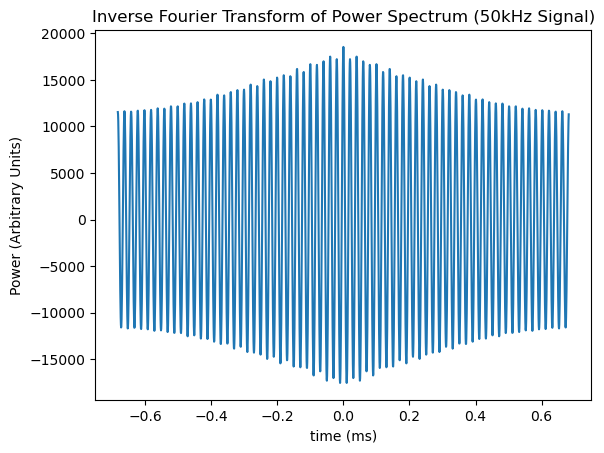

In [6]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
#N_padded = 5000
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs #Sampling period

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2
power_ifft = np.fft.ifft(power)

#N_padded = 5000
#pad_width = N_padded - N

time = np.arange(-N//2, N//2) * dt * 1000 #x-axis changed from seconds (s) to milliseconds (ms)
#padded_time = np.concatenate((time, np.zeros(pad_width)), dtype=complex)
# time = np.linspace(0, N*dt, N, endpoint=False)

#frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(time, np.fft.fftshift(power_ifft))
#plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("time (ms)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Inverse Fourier Transform of Power Spectrum (50kHz Signal)")
plt.show()

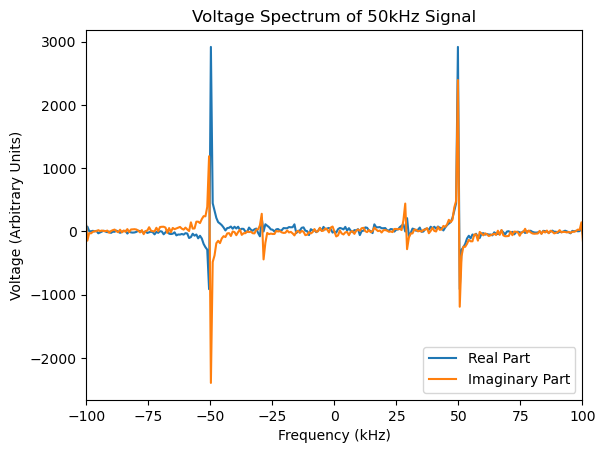

In [5]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
volt_real = np.real(fft_data)
volt_imag = np.imag(fft_data)

frequencies = np.fft.fftfreq(N, d=dt) / 1000 #x-axis changed from sample number to frequency

#positive = frequencies >= 0 
#frequencies = frequencies[positive]
#power = power[positive]

plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_real), label="Real Part")
plt.plot(np.fft.fftshift(frequencies), np.fft.fftshift(volt_imag), label="Imaginary Part")
plt.xlim(-100,100) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Voltage (Arbitrary Units)")
plt.title("Voltage Spectrum of 50kHz Signal")
plt.legend()
plt.show()